# Deliverable 2 

**Tasks** 
1) Confirm whether WINDFOR forecasts output before or after constraints.
2) Rebuild an unconstrained outturn per period (metered plus accepted bid volume, from BOALF or DISPTAV).
3) Redo Figures 1–3 against it and report the physical-notification gap.

**Bases** 
1) Primary: B1610 (232 wind BM units) + DISPTAV `Tagged` accepted bids (77 units). 
2) Sensitivity: FUELINST + Tagged. 
3) The deliverable_01 versions of the figures stay in `output/deliverable_01/`.


In [2]:
import pandas as pd 
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

ANALYSIS_DATA_PATH = Path.cwd() / "data" 
MAIN_DATA_PATH = Path.cwd().parent / "data"
OUTPUT_PATH = Path.cwd() / "output"


# The Comparator

Metered outturn plus the accepted bid volume of the same units, per settlement
period. Volumes are converted to MW levels (MWh × 2); hours average their two
periods. Walney is de-duplicated by taking the pack's `queryable` wind units as
the filter, and the `Tagged` rule sums `|pairVolumes|` (015's declared rule).


In [18]:
wind_units = set(pd.read_csv(MAIN_DATA_PATH / "wind_units.csv").loc[lambda df: df["queryable"].astype(str).str.lower() == "true", "bm_unit"])

records = []
for period in range(1, 49):
    payload = json.loads((ANALYSIS_DATA_PATH / "acceptances" / f"disptav_bid_p{period:02d}.json").read_text())
    records += [r for r in payload["data"] if r["dataType"] == "Tagged" and r["bmUnit"] in wind_units]

tagged_df = pd.DataFrame(records)
tagged_df["accepted_mwh"] = tagged_df["pairVolumes"].map(lambda pairs: sum(abs(v) for v in pairs.values() if v is not None))
tagged_by_period = tagged_df.groupby("settlementPeriod")["accepted_mwh"].sum().reindex(range(1, 49), fill_value=0.0)

b1610_by_period = pd.read_csv(MAIN_DATA_PATH / "b1610_actuals.csv").groupby("settlement_period")["quantity_mwh"].sum().reindex(range(1, 49), fill_value=0.0)

fuelinst_df = pd.read_csv(MAIN_DATA_PATH / "fuelinst_wind_5min.csv")
fuelinst_df["start_time_utc"] = pd.to_datetime(fuelinst_df["start_time_utc"], utc=True)

windfor_df = pd.read_csv(MAIN_DATA_PATH / "forecast_issues.csv")
windfor_df["publish_time_utc"] = pd.to_datetime(windfor_df["publish_time_utc"], utc=True)
windfor_df["target_start_utc"] = pd.to_datetime(windfor_df["target_start_utc"], utc=True)
day_ahead_windfor_df = windfor_df[windfor_df["publish_time_utc"] == pd.to_datetime("2026-09-07 16:30:00+00:00", utc=True)].copy()
sensitivity_windfor_df = windfor_df[windfor_df["publish_time_utc"] == pd.to_datetime("2026-09-07 23:30:00+00:00", utc=True)].copy()

periods = pd.DataFrame({
    "settlement_period": range(1, 49),
    "period_start_utc": pd.date_range("2026-09-07 23:00", periods=48, freq="30min", tz="UTC"),
    "accepted_bid_mwh": tagged_by_period.to_numpy(),
    "b1610_mwh": b1610_by_period.to_numpy(),
})
periods["accepted_bid_mw"] = periods["accepted_bid_mwh"] * 2
periods["b1610_mw"] = periods["b1610_mwh"] * 2
periods["fuelinst_mw"] = fuelinst_df.groupby("settlement_period")["generation_mw"].mean().reindex(range(1, 49)).to_numpy()
periods["unconstrained_primary_mw"] = periods["b1610_mw"] + periods["accepted_bid_mw"]
periods["unconstrained_sensitivity_mw"] = periods["fuelinst_mw"] + periods["accepted_bid_mw"]
periods.to_csv(OUTPUT_PATH / "deliverable_02" / "comparison_outconstraint_periods.csv", index=False)

hours = pd.date_range("2026-09-07 23:00", periods=24, freq="h", tz="UTC")
hour_of_period = np.arange(48) // 2
comparison_df = periods.groupby(hour_of_period).mean(numeric_only=True)
comparison_df["hour_start_utc"] = hours
comparison_df["windfor_da_mw"] = day_ahead_windfor_df.set_index("target_start_utc")["forecast_mw"].reindex(hours).to_numpy()
comparison_df["windfor_sens_mw"] = sensitivity_windfor_df.set_index("target_start_utc")["forecast_mw"].reindex(hours).to_numpy()
comparison_df["err_da_vs_primary_mw"] = comparison_df["windfor_da_mw"] - comparison_df["unconstrained_primary_mw"]
comparison_df["err_da_vs_sensitivity_mw"] = comparison_df["windfor_da_mw"] - comparison_df["unconstrained_sensitivity_mw"]
comparison_df["err_sens_vs_primary_mw"] = comparison_df["windfor_sens_mw"] - comparison_df["unconstrained_primary_mw"]
comparison_df.to_csv(OUTPUT_PATH / "deliverable_02" / "comparison_outconstraint.csv", index=False)
comparison_df.round().head()


,settlement_period,accepted_bid_mwh,b1610_mwh,accepted_bid_mw,b1610_mw,fuelinst_mw,unconstrained_primary_mw,unconstrained_sensitivity_mw,hour_start_utc,windfor_da_mw,windfor_sens_mw,err_da_vs_primary_mw,err_da_vs_sensitivity_mw,err_sens_vs_primary_mw
0,2.0,2871.0,5036.0,5741.0,10073.0,11305.0,15814.0,17046.0,2026-09-07 23:00:00+00:00,16049,14733,235.0,-997.0,-1081.0
1,4.0,2835.0,5070.0,5669.0,10140.0,11469.0,15810.0,17138.0,2026-09-08 00:00:00+00:00,16596,15732,786.0,-542.0,-78.0
2,6.0,2563.0,6052.0,5125.0,12104.0,13484.0,17229.0,18609.0,2026-09-08 01:00:00+00:00,17002,16589,-227.0,-1607.0,-640.0
3,8.0,2513.0,6433.0,5025.0,12866.0,14251.0,17891.0,19276.0,2026-09-08 02:00:00+00:00,17355,17301,-536.0,-1921.0,-590.0
4,10.0,2444.0,6673.0,4888.0,13345.0,14771.0,18233.0,19659.0,2026-09-08 03:00:00+00:00,17538,17634,-695.0,-2121.0,-599.0


# Before or after constraints?

A forecast of **delivered output** should sit on the metered line; a forecast
of the **resource** should sit on metered plus the volume the network
instructed off. The comparison answers the question by level, not by a
regression: the forecast's error against each candidate actual.


In [4]:
comparisons = {
    "Unconstrained: B1610 + bids (primary)": "unconstrained_primary_mw",
    "Unconstrained: FUELINST + bids (sensitivity)": "unconstrained_sensitivity_mw",
    "Constrained: B1610 metered (contrast)": "b1610_mw",
    "Constrained: FUELINST (contrast)": "fuelinst_mw",
}
rows = {}
for label, column in comparisons.items():
    error = comparison_df["windfor_da_mw"] - comparison_df[column]
    rows[label] = {
        "MAE MW": error.abs().mean(),
        "RMSE MW": np.sqrt((error**2).mean()),
        "bias MW": error.mean(),
    }
stats = pd.DataFrame(rows).T

share = (comparison_df["windfor_da_mw"] - comparison_df["b1610_mw"]).mean() / comparison_df["accepted_bid_mw"].mean()
residual = comparison_df["windfor_da_mw"] - comparison_df["unconstrained_primary_mw"]
share_ci = 1.96 * residual.std(ddof=1) / np.sqrt(len(residual)) / comparison_df["accepted_bid_mw"].mean()
print(f"day-mean share of accepted volume in the forecast gap from metered: {share:.2f} ± {share_ci:.2f}")
stats.round(0)


day-mean share of accepted volume in the forecast gap from metered: 1.03 ± 0.08


,MAE MW,RMSE MW,bias MW
Unconstrained: B1610 + bids (primary),864.0,1025.0,159.0
Unconstrained: FUELINST + bids (sensitivity),1420.0,1641.0,-1115.0
Constrained: B1610 metered (contrast),5109.0,5208.0,5109.0
Constrained: FUELINST (contrast),3836.0,4027.0,3836.0


**Reading:** The forecast's mean absolute error is 0.86 GW against metered
plus accepted bids (primary) and 5.11 GW against metered (six times larger)
and its day-mean gap from metered equals the accepted bid volume (share
1.03 ± 0.08). WINDFOR behaves like a pre-constraint resource forecast on this
day: its offset from delivered output is the day's curtailment, not an error.

**What's the caveat?** The unconstrained series is a reconstruction, metered
plus accepted bid volume, so this evidence is only as good as that
reconstruction, which the BOALF cross-check below (−0.20 %) and 015's
settlement reconciliation support.

# BOALF Cross-check

Instructed levels are not reductions. A unit accepted down from a 74 MW notification to 0 MW has been reduced by 74 MW, not 0. 
The check integrates max(0, PN(t) − level(t)) over every acceptance, with the acceptance carrying the latest acceptanceTime governing where spans overlap, and reconciles with Tagged at −0.20 %.


In [5]:
pn_df = pd.read_csv(MAIN_DATA_PATH / "pn_final.csv")
pn_df["time_from_utc"] = pd.to_datetime(pn_df["time_from_utc"], utc=True)
pn_df["time_to_utc"] = pd.to_datetime(pn_df["time_to_utc"], utc=True)
pn_segments = {
    unit: list(group[["time_from_utc", "time_to_utc", "level_from_mw", "level_to_mw"]].itertuples(index=False, name=None))
    for unit, group in pn_df.groupby("bm_unit")
}

boalf = []
for period in range(1, 49):
    payload = json.loads((ANALYSIS_DATA_PATH / "acceptances" / f"boalf_p{period:02d}.json").read_text())
    boalf += [r for r in payload["data"] if r["bmUnit"] in wind_units]
boalf_df = pd.DataFrame(boalf)
for column, source in (("t0", "timeFrom"), ("t1", "timeTo"), ("at", "acceptanceTime")):
    boalf_df[column] = pd.to_datetime(boalf_df[source], utc=True)

minutes = pd.date_range("2026-09-07 23:00", periods=1440, freq="min", tz="UTC")


def pn_level(segments, moment):
    for t0, t1, p0, p1 in segments:
        if t0 <= moment < t1:
            return p0 + (p1 - p0) * (moment - t0).total_seconds() / (t1 - t0).total_seconds()
    return None


tagged_unit_mwh = tagged_df.groupby("bmUnit")["accepted_mwh"].sum()
boalf_unit_mwh, skipped = {}, 0
for unit, group in boalf_df.groupby("bmUnit"):
    segments = pn_segments.get(unit)
    if segments is None:
        skipped += group.shape[0]
        continue
    active = group.sort_values(["at", "acceptanceNumber"])
    total = 0.0
    # ponytail: 1-minute sampling; exact breakpoint integration if the 2 % gate ever tightens.
    for minute in minutes:
        candidates = active[(active["t0"] <= minute) & (active["t1"] > minute)]
        if candidates.empty:
            continue
        row = candidates.iloc[-1]
        level = row["levelFrom"] + (row["levelTo"] - row["levelFrom"]) * (minute - row["t0"]).total_seconds() / (row["t1"] - row["t0"]).total_seconds()
        pn = pn_level(segments, minute)
        if pn is not None and pn > level:
            total += (pn - level) / 60
    boalf_unit_mwh[unit] = total

checked = [u for u in tagged_unit_mwh.index if u in boalf_unit_mwh]
boalf_total = sum(boalf_unit_mwh[u] for u in checked)
tagged_total = tagged_unit_mwh[checked].sum()
print(
    f"BOALF {boalf_total:,.0f} MWh vs Tagged {tagged_total:,.0f} MWh "
    f"over {len(checked)} units: {(boalf_total - tagged_total) / tagged_total * 100:+.2f}% "
    f"(gate 2%); spans skipped for missing PN: {skipped}"
)


BOALF 118,564 MWh vs Tagged 118,805 MWh over 77 units: -0.20% (gate 2%); spans skipped for missing PN: 0


# Timeseries Plots


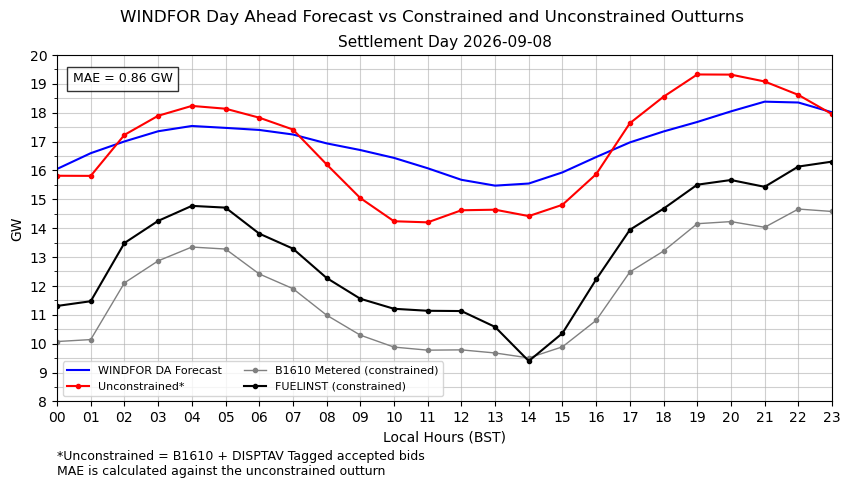

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.grid(visible=True, which="both", axis="both", alpha=0.6)
plt.rcParams["timezone"] = "Europe/London"

hours_london = comparison_df["hour_start_utc"].dt.tz_convert("Europe/London")
mae = np.abs(comparison_df["err_da_vs_primary_mw"]).mean() / 1000

ax.plot(hours_london, comparison_df["windfor_da_mw"] / 1000, label="WINDFOR DA Forecast", color="blue")
ax.plot(hours_london, comparison_df["unconstrained_primary_mw"] / 1000, label="Unconstrained*", color="red", marker='o', markersize=3)
ax.plot(hours_london, comparison_df["b1610_mw"] / 1000, label="B1610 Metered (constrained)", color="grey", lw=1, marker='o', markersize=3)
ax.plot(hours_london, comparison_df["fuelinst_mw"] / 1000, label="FUELINST (constrained)", color="black", marker='o', markersize=3)

ax.set_yticks(np.arange(8, 21, 1))
ax.set_yticks(np.arange(8, 20.5, 0.5), minor=True)

ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax.margins(x=0)

fig.suptitle("WINDFOR Day Ahead Forecast vs Constrained and Unconstrained Outturns", fontsize=12)
ax.set_title("Settlement Day 2026-09-08", fontsize=11)
ax.set_ylabel("GW")
ax.set_xlabel("Local Hours (BST)")

ax.annotate(
    "*Unconstrained = B1610 + DISPTAV Tagged accepted bids\nMAE is calculated against the unconstrained outturn",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)

ax.text(
    0.02, 0.95,
    f"MAE = {mae:.2f} GW",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

ax.legend(ncol=2, fontsize=8)
fig.savefig(OUTPUT_PATH / "deliverable_02" / "windfor_vs_fuelinst_outconstraint.png", dpi=150, bbox_inches="tight")
plt.show()


# WINDFOR Error Progression Heatmap


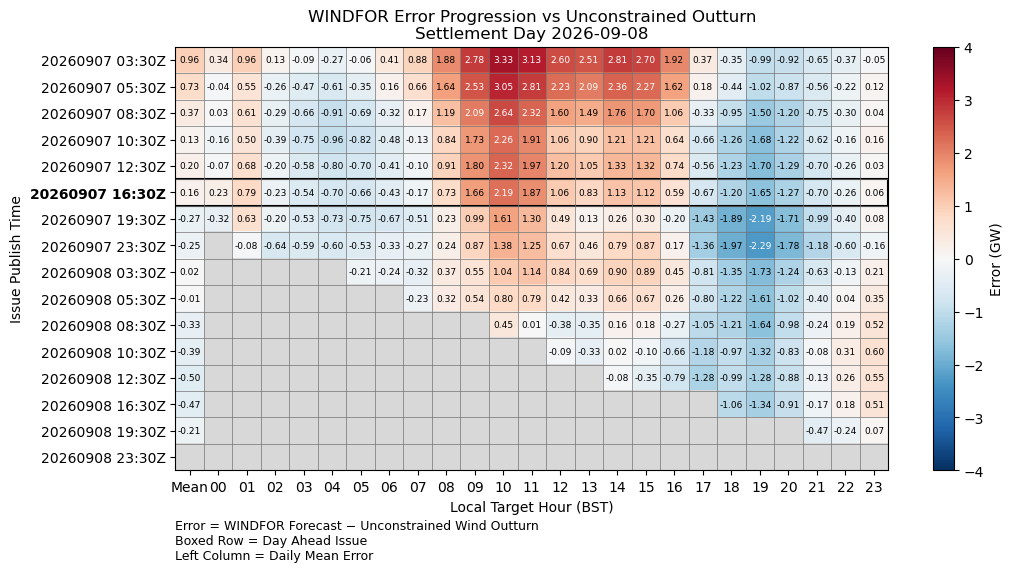

In [15]:
error = (windfor_df.pivot(index="publish_time_utc", columns="target_start_utc", values="forecast_mw").sub(comparison_df.set_index("hour_start_utc")["unconstrained_primary_mw"], axis=1) / 1000)
retro = error.index.to_numpy()[:, None] >= error.columns.to_numpy()[None, :]
error = error.mask(retro)

mean_error = error.mean(axis=1)
display = np.column_stack([mean_error.to_numpy(), error.to_numpy()])

vmax = np.ceil(np.nanmax(np.abs(display)))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("0.85")

fig, ax = plt.subplots(figsize=(11.5, 5.5))
im = ax.imshow(display, aspect="auto", origin="upper", cmap=cmap,
               vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_xticks(range(display.shape[1]),
              ["Mean"] + error.columns.tz_convert("Europe/London").strftime("%H").tolist())
ax.set_yticks(range(error.shape[0]), [f"{t:%Y%m%d %H:%M}Z" for t in error.index])
ax.set_xticks(np.arange(display.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(error.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="0.45", linewidth=0.5)
ax.tick_params(which="minor", length=0)

da = list(error.index).index(pd.Timestamp("2026-09-07 16:30:00+00:00"))
ax.axhspan(da - 0.5, da + 0.5, fill=False, edgecolor="black", lw=1.5)
ax.get_yticklabels()[da].set_fontweight("bold")

for (i, j), value in np.ndenumerate(display):
    if np.isfinite(value):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(value) > vmax / 2 else "black")

ax.set_title("WINDFOR Error Progression vs Unconstrained Outturn\nSettlement Day 2026-09-08")
ax.set_xlabel("Local Target Hour (BST)")
ax.set_ylabel("Issue Publish Time")

ax.annotate(
    "Error = WINDFOR Forecast − Unconstrained Wind Outturn\nBoxed Row = Day Ahead Issue\nLeft Column = Daily Mean Error",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)
fig.colorbar(im, ax=ax, label="Error (GW)", shrink=1)
fig.savefig(OUTPUT_PATH / "deliverable_02" / "windfor_error_prog_outconstraint.png", dpi=150, bbox_inches="tight")
plt.show()


# DGWS Day Ahead Forecast vs Unconstrained Outturn

DGWS and AGWS cover a wider wind population than the BM-unit reconstruction
(embedded wind is invisible to transmission metering), so this figure's MAE is
not comparable with Figure 1's; the unconstrained line is the requested
reference.


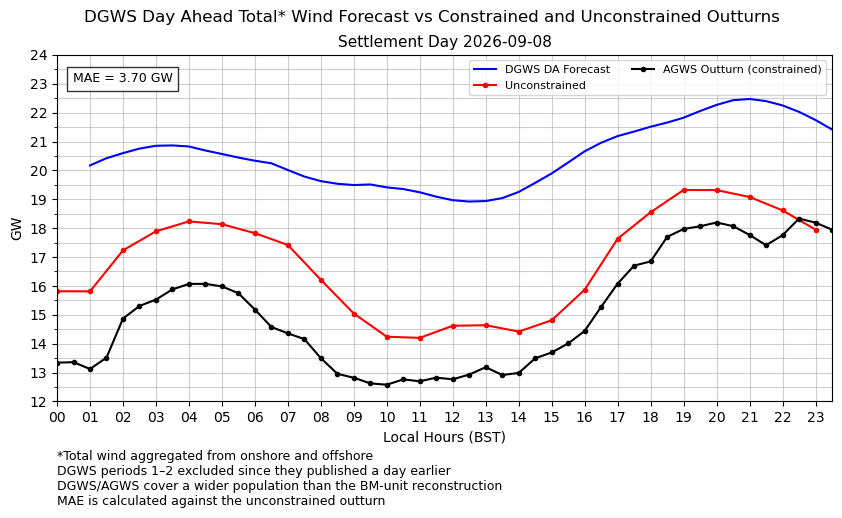

In [ ]:
dgws_df = pd.read_csv(MAIN_DATA_PATH / "b1440_day_ahead.csv")
dgws_df["target_start_utc"] = pd.to_datetime(dgws_df["target_start_utc"], utc=True)
dgws_df = dgws_df[dgws_df["settlement_period"] >= 3]
total_wind_dgws_df = (dgws_df[dgws_df["psr_type"].isin(["Wind Onshore", "Wind Offshore"])]
                      .groupby("target_start_utc", as_index=False).agg(quantity_mw=("quantity_mw", "sum")))
total_wind_dgws_df["target_start_london"] = total_wind_dgws_df["target_start_utc"].dt.tz_convert("Europe/London")

agws_df = pd.DataFrame(json.loads((ANALYSIS_DATA_PATH / "agws_2026-09-08.json").read_text())["data"])
agws_df["startTime"] = pd.to_datetime(agws_df["startTime"], utc=True)
total_wind_agws_df = (agws_df[agws_df["psrType"].isin(["Wind Onshore", "Wind Offshore"])]
                      .groupby("startTime", as_index=False).agg(quantity_mw=("quantity", "sum")))
total_wind_agws_df["startTimeLondon"] = total_wind_agws_df["startTime"].dt.tz_convert("Europe/London")

unconstrained_by_hour = comparison_df.set_index("hour_start_utc")["unconstrained_primary_mw"]
dgws_by_hour = total_wind_dgws_df.set_index("target_start_utc")["quantity_mw"].reindex(hours)
mae = np.nanmean(np.abs(dgws_by_hour.to_numpy() - unconstrained_by_hour.reindex(hours).to_numpy())) / 1000

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.grid(visible=True, which="both", axis="both", alpha=0.6)
plt.rcParams["timezone"] = "Europe/London"

ax.plot(total_wind_dgws_df["target_start_london"], total_wind_dgws_df["quantity_mw"] / 1000, label="DGWS DA Forecast", color="blue")
ax.plot(comparison_df["hour_start_utc"].dt.tz_convert("Europe/London"), comparison_df["unconstrained_primary_mw"] / 1000, label="Unconstrained", color="red", marker='o', markersize=3)
ax.plot(total_wind_agws_df["startTimeLondon"], total_wind_agws_df["quantity_mw"] / 1000, label="AGWS Outturn (constrained)", color="black", marker='o', markersize=3)

ax.set_yticks(np.arange(12, 25, 1))
ax.set_yticks(np.arange(12, 24.5, 0.5), minor=True)

ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax.margins(x=0)

fig.suptitle("DGWS Day Ahead Total* Wind Forecast vs Constrained and Unconstrained Outturns", fontsize=12)
ax.set_title("Settlement Day 2026-09-08", fontsize=11)
ax.set_ylabel("GW")
ax.set_xlabel("Local Hours (BST)")

ax.annotate(
    "*Total wind aggregated from onshore and offshore\nDGWS periods 1–2 excluded since they published a day earlier\nDGWS/AGWS cover a wider population than the BM-unit reconstruction\nMAE is calculated against the unconstrained outturn",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)

ax.text(
    0.02, 0.95,
    f"MAE = {mae:.2f} GW",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

ax.legend(ncol=2, fontsize=8)
fig.savefig(OUTPUT_PATH / "deliverable_02" / "dgws_vs_agws_outconstraint.png", dpi=150, bbox_inches="tight")
plt.show()


# Physical Notifications

The 227-unit PN integral (trapezoidal over its segments, no interpolation)
against metered + bids on both bases.


In [8]:
pn_total_mwh = sum(
    (p0 + p1) / 2 * (t1 - t0).total_seconds() / 3600
    for segments in pn_segments.values()
    for t0, t1, p0, p1 in segments
)
pn_mean_mw = pn_total_mwh / 24

pn_gap = pd.DataFrame({
    "mean MW": [
        pn_mean_mw,
        comparison_df["b1610_mw"].mean(),
        comparison_df["accepted_bid_mw"].mean(),
        comparison_df["unconstrained_primary_mw"].mean(),
        comparison_df["unconstrained_sensitivity_mw"].mean(),
    ],
}, index=["PN (227 units)", "B1610 metered", "Accepted bids", "B1610 + bids", "FUELINST + bids"])
pn_gap["PN − mean MW"] = pn_mean_mw - pn_gap["mean MW"]
pn_gap.round(1)


,mean MW,PN − mean MW
PN (227 units),17890.7,0.0
B1610 metered,11835.8,6055.0
Accepted bids,4950.2,12940.5
B1610 + bids,16786.0,1104.8
FUELINST + bids,18059.1,-168.3


**Reading.** The physical notifications average 17,891 MW, 1,105 MW above
B1610 + bids and 168 MW *below* FUELINST + bids, so the
gap is population dependent. It is either the generators' own forecast error
or over declaration. This deliverable does not decide which.
